In [84]:
from io import StringIO
import pandas as pd
from pathlib import Path
import textwrap
import matplotlib.pyplot as plt
import numpy as np

In [85]:
# The path to folder containing result files.
results_path = '../results'

ignored_files = ['real_estimates.csv','real_estimates copy.csv', 'cms.old', 'cms.old.2']

In [86]:
# Change as needed.
# fname: the filename for the dataset.
def get_dataset_name(fname):
  file = fname.split('.csv')[0]
  
  if file.startswith('gen0_'):
    return 'Normal Distribution'
  elif file.startswith('gen1_'):
    return 'Uniform Distribution'
  elif file.startswith('tax_'):
    return 'Tax'
  elif file.startswith('flights_'):
    return 'Flights'
  elif file.startswith('lineitem_'):
    return 'TPC-H'
  else:
    return 'Unknown Workload'

In [87]:
column_names = ['algorithm', 'predicate', 'table_size', 'estimate', 'build_time', 'estimation_time']

result_files = [result for result in Path(results_path).glob("*") if result.name not in ignored_files]

results = []

for result_path in result_files:
  with open(result_path, 'r') as file:
      content = file.read()
  
  batches = [batch.strip() for batch in content.strip().split('\n\n') if batch.strip()]
  
  for batch in batches:
    batch_df = pd.read_csv(StringIO(batch), header=None, names=column_names)

    total_row = batch_df[batch_df['predicate'] == 'TOTAL']
    
    if total_row.empty:
        continue

    summary = total_row.iloc[0]
    filename = summary['table_size'] # last row contains the filename in 'table_size' column
    batch_df = batch_df[batch_df['predicate'] != 'TOTAL']

    aggregated = batch_df.groupby('predicate').agg({
        'estimate': 'mean',
        'build_time': 'mean',
        'estimation_time': 'mean',
        'table_size': 'first'
    }).reset_index()
    
    aggregated['table_size'] = pd.to_numeric(aggregated['table_size'], errors='coerce')

    aggregated['algorithm'] = summary['algorithm']
    aggregated['table'] = filename
    aggregated['dataset_name'] = get_dataset_name(filename)

    results.append(aggregated)

final_results = pd.concat(results, ignore_index=True)

display(final_results)

,predicate,estimate,build_time,estimation_time,table_size,algorithm,table,dataset_name
0,age = age,2.502080e+06,8.61426,0.30056,10000,COUNT-MIN-SKETCH,gen0_10000.csv,Normal Distribution
1,age = age AND department = department,2.502080e+06,28.26266,0.27848,10000,COUNT-MIN-SKETCH,gen0_10000.csv,Normal Distribution
2,department = department,1.000000e+08,7.73368,0.30286,10000,COUNT-MIN-SKETCH,gen0_10000.csv,Normal Distribution
3,age = age,2.496250e+08,79.52558,0.26768,100000,COUNT-MIN-SKETCH,gen0_100000.csv,Normal Distribution
4,age = age AND department = department,2.496250e+08,278.87740,0.27102,100000,COUNT-MIN-SKETCH,gen0_100000.csv,Normal Distribution
...,...,...,...,...,...,...,...,...
85,age = age AND department = department,2.620768e+13,64795.56000,0.04752,1000000,TUG-OF-WAR,gen1_1000000.csv,Uniform Distribution
86,department = department,1.156574e+13,30279.38000,0.04726,1000000,TUG-OF-WAR,gen1_1000000.csv,Uniform Distribution
87,age = age,9.735130e+11,64285.24000,0.04664,2000000,TUG-OF-WAR,gen1_2000000.csv,Uniform Distribution
88,age = age AND department = department,1.048270e+14,129564.20000,0.04698,2000000,TUG-OF-WAR,gen1_2000000.csv,Uniform Distribution


In [88]:
real_estimates = pd.read_csv(f'{results_path}/real_estimates.csv')
real_estimates['dataset_name'] = real_estimates['dataset_fname'].apply(get_dataset_name)

display(real_estimates.head(n=10))

,experiment_fname,dataset_fname,predicate,real_estimate,dataset_name
0,flights,flights_1000000.csv,Origin = Origin,13525562981,Flights
1,flights,flights_1000000.csv,Origin = Origin AND Destination = Destination,1316309219,Flights
2,flights_100k,flights_100000.csv,Origin = Origin,134673200,Flights
3,flights_100k,flights_100000.csv,Origin = Origin AND Destination = Destination,13260402,Flights
4,flights_10k,flights_10000.csv,Origin = Origin,1337610,Flights
5,flights_10k,flights_10000.csv,Origin = Origin AND Destination = Destination,140538,Flights
6,flights_500k,flights_500000.csv,Origin = Origin,3377643328,Flights
7,flights_500k,flights_500000.csv,Origin = Origin AND Destination = Destination,329246758,Flights
8,gen0_100k,gen0_100000.csv,age = age,249625474,Normal Distribution
9,gen0_100k,gen0_100000.csv,age = age AND department = department,71751740,Normal Distribution


In [89]:
unique_pairs = final_results[['dataset_name', 'predicate']].drop_duplicates().reset_index(drop=True)
association_map = {}

for idx, (dataset_name, predicate) in unique_pairs.iterrows():
  symbol = f"$\\varphi_{{{idx + 1}}}$"
  association_map[(dataset_name, predicate)] = symbol

experiments_data = [
  (dataset_name, predicate, '\n'.join(textwrap.wrap(predicate, width=30)), symbol)
  for (dataset_name, predicate), symbol in association_map.items()
]
experiments_df = pd.DataFrame(experiments_data, columns=['Table', 'Predicate', 'Predicate Text', 'Symbol'])

display(experiments_df)

,Table,Predicate,Predicate Text,Symbol
0,Normal Distribution,age = age,age = age,$\varphi_{1}$
1,Normal Distribution,age = age AND department = department,age = age AND department =\ndepartment,$\varphi_{2}$
2,Normal Distribution,department = department,department = department,$\varphi_{3}$
3,Uniform Distribution,age = age,age = age,$\varphi_{4}$
4,Uniform Distribution,age = age AND department = department,age = age AND department =\ndepartment,$\varphi_{5}$
5,Uniform Distribution,department = department,department = department,$\varphi_{6}$


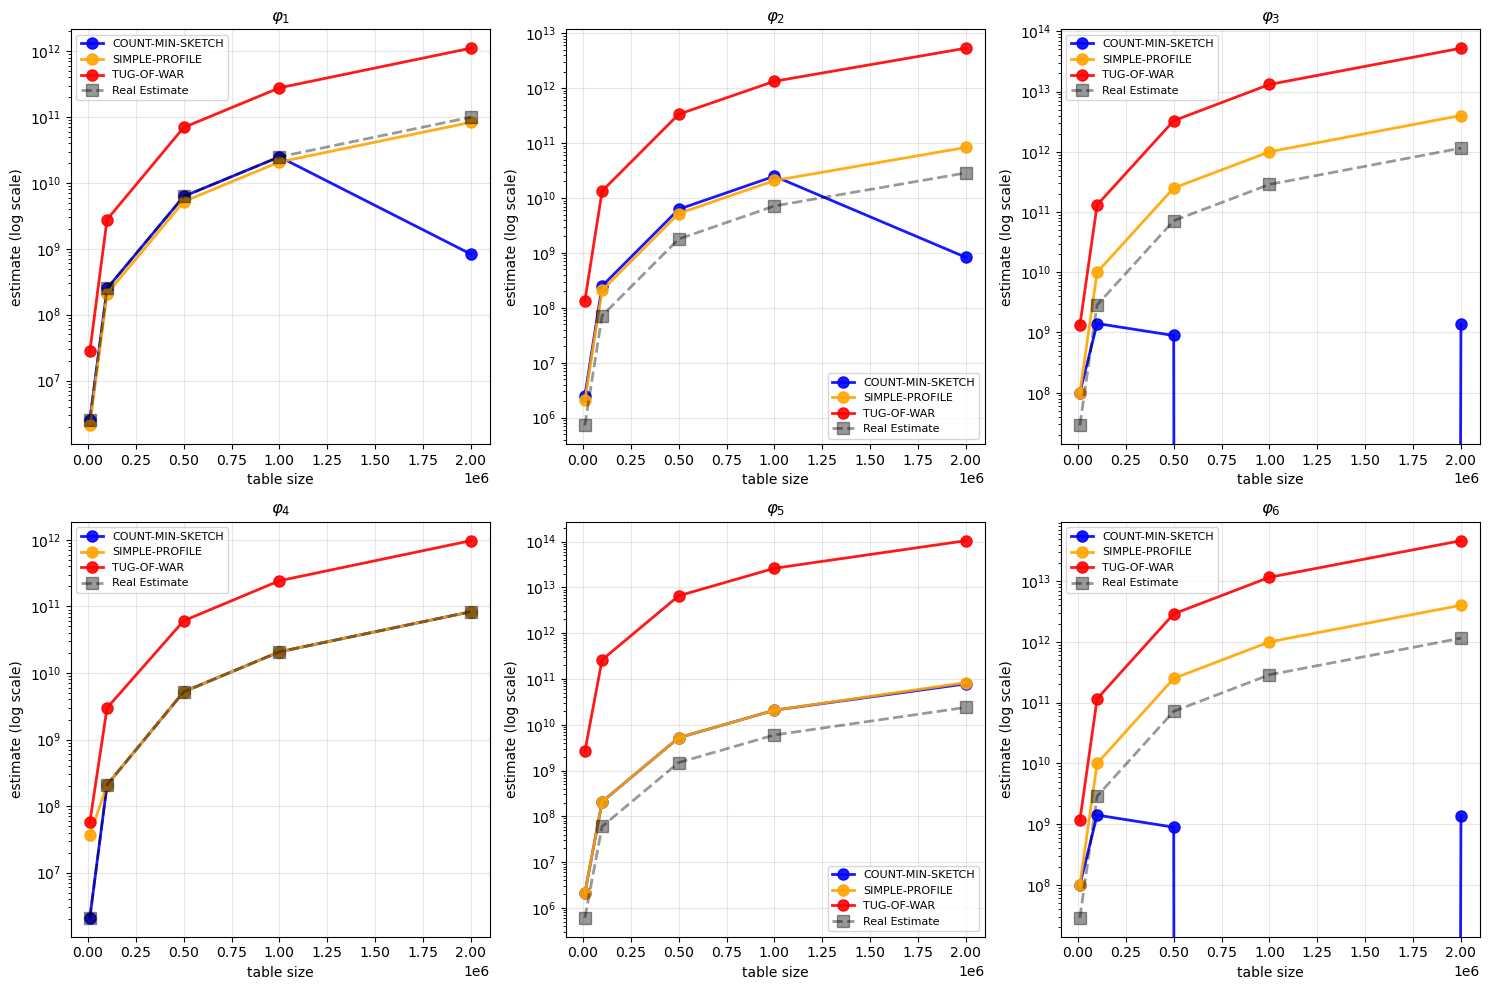

In [90]:
# Configurar o layout do subplot
n_experiments = len(experiments_df)
n_cols = 3
n_rows = int(np.ceil(n_experiments / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_experiments > 1 else [axes]

# Cores para os algoritmos
algorithm_colors = {
    'COUNT-MIN-SKETCH': 'blue',
    'TUG-OF-WAR': 'red',
    'SIMPLE-PROFILE': 'orange'
}

# Iterar sobre cada experimento
for idx, (_, exp_row) in enumerate(experiments_df.iterrows()):
    ax = axes[idx]
    dataset_name = exp_row['Table']
    predicate = exp_row['Predicate']
    symbol = exp_row['Symbol']
    
    # Filtrar dados do experimento
    exp_data = final_results[
        (final_results['dataset_name'] == dataset_name) & 
        (final_results['predicate'] == predicate)
    ]
    
    # Plotar linha para cada algoritmo
    for algorithm in exp_data['algorithm'].unique():
        alg_data = exp_data[exp_data['algorithm'] == algorithm].sort_values('table_size')
        
        ax.plot(
            alg_data['table_size'], 
            alg_data['estimate'],
            marker='o',
            markersize=8,
            color=algorithm_colors.get(algorithm, 'gray'),
            linewidth=2,
            label=algorithm,
            alpha=0.9 # opacity
        )
    
    # Adicionar linha da estimativa real
    real_data = real_estimates[
        (real_estimates['dataset_name'] == dataset_name) & 
        (real_estimates['predicate'] == predicate)
    ]
    
    if not real_data.empty:
        # Extrair table_size do dataset_fname
        real_data_with_size = real_data.copy()
        real_data_with_size["table_size"] = (
            real_data_with_size["dataset_fname"]
            .str.split("_")
            .str[-1]
            .str.split(".csv")
            .str[0]
            .astype(int)
        )
        real_data_with_size = real_data_with_size.sort_values("table_size")
        # display(real_data_with_size)
        
        
        ax.plot(
            real_data_with_size['table_size'],
            real_data_with_size['real_estimate'],
            marker='s',
            markersize=8,
            color='black',
            linewidth=2,
            linestyle='--',
            label='Real Estimate',
            alpha=0.4
        )
    
    # Configurar o plot
    ax.set_yscale('log')
    ax.set_xlabel('table size', fontsize=10)
    ax.set_ylabel('estimate (log scale)', fontsize=10)
    ax.set_title(f'{symbol}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

# Remover subplots vazios
for idx in range(n_experiments, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [91]:
# DEBUG

display(final_results.query(
    '(algorithm == "SIMPLE-PROFILE" | algorithm == "COUNT-MIN-SKETCH") & '
    'predicate == "age = age" & dataset_name == "Uniform Distribution"'
))


,predicate,estimate,build_time,estimation_time,table_size,algorithm,table,dataset_name
15,age = age,2.092030e+06,8.246620,0.276380,10000,COUNT-MIN-SKETCH,gen1_10000.csv,Uniform Distribution
18,age = age,2.084120e+08,78.863960,0.263760,100000,COUNT-MIN-SKETCH,gen1_100000.csv,Uniform Distribution
21,age = age,5.208890e+09,391.349000,0.261300,500000,COUNT-MIN-SKETCH,gen1_500000.csv,Uniform Distribution
24,age = age,2.083460e+10,799.643400,0.266420,1000000,COUNT-MIN-SKETCH,gen1_1000000.csv,Uniform Distribution
27,age = age,8.333640e+10,1592.568000,0.265440,2000000,COUNT-MIN-SKETCH,gen1_2000000.csv,Uniform Distribution
45,age = age,3.645828e+07,4.162900,0.000717,10000,SIMPLE-PROFILE,gen1_10000.csv,Uniform Distribution
48,age = age,2.083330e+08,15.154175,0.000600,100000,SIMPLE-PROFILE,gen1_100000.csv,Uniform Distribution
51,age = age,5.208330e+09,84.178000,0.001000,500000,SIMPLE-PROFILE,gen1_500000.csv,Uniform Distribution
54,age = age,2.083330e+10,173.683400,0.001040,1000000,SIMPLE-PROFILE,gen1_1000000.csv,Uniform Distribution
57,age = age,8.333330e+10,358.168200,0.001100,2000000,SIMPLE-PROFILE,gen1_2000000.csv,Uniform Distribution
